# Step 6 — SPECTRAL FITTING · burst #21 `bn110920546`
**Status: PRESENTED — gate pending.** Numbers-verifier round on this table: see §7. Figure: see §5 (figure-verifier round recorded in `VISION_QC.md`).

What the fitted spectra say, block by block, on the **promoted widened-bounds table** (β floor −10, SBPL α ceiling 2.5; PI ruling 2026-09-02 "let it go till −10 like XSPEC").
The two earlier generations of this table (pre-amendment 09-01 and β-floor −5 09-02) are quarantined with manifests; nothing from them is quoted here.

Skill file: `dev/ai_guides/SpectralFitting.md` (rulings A/B, evolution-track ruling, bounds ruling, L6/L6b, L12, L15, L16, L24, L25, L28, L31–L33).
Engine: `scripts/10_spectral_fit_burst.py` at commit `82737c9`. Every count below carries its three coordinates (denominator / basis / model) — rule PRESENT-1, register NR-45.

In [1]:
import os, sys, json, glob, hashlib, ast, subprocess, numpy as np
from astropy.table import Table
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
BURST = "bn110920546"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
rel = lambda p: os.path.join(ROOT, p)
appr = json.load(open(rel(f"results/sweep106/{BURST}/APPROVALS.json")))
print("repo:", ROOT, "| burst:", BURST)

repo: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks | burst: bn110920546


In [2]:
STEP = "6"

In [3]:
s = appr[STEP]
print(f'step {STEP}: {s["status"]}  by {s["by"]}  {s["utc"]}')
for f in s.get("feedback", []):
    print(f'\n  PI feedback: {f["text"][:400]}')

step 6: PRESENTED  by Claude session (GRBs Agent, walkthrough seat) — RE-PRESENTED on the promoted widened-bounds table sha 45104924 (beta floor -10, SBPL alpha 2.5; PI ruling 2026-09-02); A9 NUMBERS PASS 13/13 traceable, CLAIM PROMOTION CONDITIONAL FAIL folded into notebook step6 §3/§6b/§7; code auditor dev/fit_table_audit.py agrees cell-for-cell; figure step6_cpl_track.png in A8 round 8  2026-09-03T00:06:21Z


## 1. The table and its lineage
The object being presented is ONE file. Its sha256 is pinned in `CAMPAIGN_COMMIT_PIN.json` under `bn110920546_step6_WIDENED`; the engine's bounds are read from the engine source with `ast` (never re-typed — NR-10).

In [4]:
TAB = rel(f"results/convention_check/{BURST}/spectral_fits.ecsv")
pin_all = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))
pin = pin_all["gate_verdicts_hash_bound"][f"{BURST}_step6_WIDENED"]
TAB_SHA = sha(TAB)
print("table:", TAB); print("sha256:", TAB_SHA)
print("matches the pinned widened-generation sha?", pin.get("artifact_sha256") == TAB_SHA)
print("pin says:", {k: v for k, v in pin.items() if k != "artifact_sha256"})
t = Table.read(TAB, format="ascii.ecsv")
print(f"rows: {len(t)} (BLOCK {int(t['BLOCK'].min())}..{int(t['BLOCK'].max())}; -1 = T_INT)")
# the engine's own constants, via ast (the building seat's auditor exposes exactly these readers)
sys.path.insert(0, rel("dev"))
import fit_table_audit as FTA
tree = FTA._engine_tree()
SPEC_LIST = FTA.engine_specs(tree)                      # [(name, prefix, n_params)] read from the engine with ast
SPECS = {n: dict(prefix=p, n_params=k) for n, p, k in SPEC_LIST}
PARENTS = FTA.engine_nested_parents(tree); PARAM_BOUNDS, EAC_BOUNDS = FTA.engine_bounds(tree)
roots = {m for ps in PARENTS.values() for m in ps} - set(PARENTS)
print("models in engine spec:", len(SPECS), "| nested children:", len(PARENTS), "| roots:", sorted(roots))
print("ancestor-less NON-root models (NR-41):", sorted(m for m in SPECS if m not in PARENTS and m not in roots))
print("EAC box:", EAC_BOUNDS)
print("engine PARAM_BOUNDS for beta / SBPL alpha (the widened bounds):", {k: v for k, v in PARAM_BOUNDS.items() if k.endswith("BETA") and k.split("_")[0] in ("BAND","SBPL","DSBPL")} | {k: v for k, v in PARAM_BOUNDS.items() if k in ("SBPL_ALPHA",)})
# quarantined generations: listed, never quoted
for q in sorted(glob.glob(rel(f"results/convention_check/{BURST}/_superseded_*"))):
    man = glob.glob(os.path.join(q, "*MANIFEST*.json"))
    print("quarantine:", os.path.basename(q), "| manifest:", os.path.basename(man[0]) if man else "NONE")

table: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks/results/convention_check/bn110920546/spectral_fits.ecsv
sha256: 45104924a75761122e170bac32a6e8ab9b6492b1dc62eedbe057844811e34225
matches the pinned widened-generation sha? True
pin says: {'recorded_utc': '2026-09-02T23:50:25Z', 'artifact': 'results/convention_check/bn110920546/spectral_fits.ecsv', 'supersedes': 'bn110920546_step6 (beta=-5 generation, quarantined _superseded_beta5_20260902)', 'state': 'S5_PROMOTED, 0 FAIL cells, receipt present', 'numbers_verdict': 'A9 2026-09-02 (NUMBERS_QC_bn110920546_step6_widened.md): NUMBERS PASS — 13/13 traceable, 11 exact; CLAIM PROMOTION CONDITIONAL FAIL — DECISIVE extra components are low-energy (<20 keV) edge features (PL index ~-3.6 with PL_K on the 1e-15 floor at the 100 MeV pivot, or BB kT 1-3 keV) with EAC railed 11/12; blk-4 adopted flipped CPL+BB->SBPL+PL between generations (0.14 AIC); T_INT margin 7.81 is a validity artefact (SBPL+CPL twin invalid on the HE_XC floor)', 'numbers

## 2. Every count with its three coordinates (NR-45)
Two computations of the same counts. **(a)** the code auditor `dev/fit_table_audit.py` (NR-42..45 as CODE, built by the building seat 2026-09-02) run here on the promoted table; **(b)** an independent in-notebook recompute from the raw columns. They must agree cell for cell.

Definitions (PI ruling 3, 2026-08-30): candidate set = `<M>_AIC` finite AND `<M>_VALID` AND `<M>_STATUS` not FAIL/ERROR. **TIE** = ΔAIC < 2 vs the argmin. **TRACKED** = ΔAIC > 6 vs runner-up. **DECISIVE** = ΔAIC ≥ 10 vs the best simpler ancestor in `NESTED_PARENTS` (chain gate); models without an ancestor are **UNDEFINED**. **Adopted** (ruling A, 2026-09-01) = the tie member with the fewest free parameters, equal → lowest AIC.

In [5]:
OUT = rel(f"results/sweep106/{BURST}")
r = subprocess.run([sys.executable, rel("dev/fit_table_audit.py"), "--table", TAB, "--out-dir", OUT, "--quiet"], capture_output=True, text=True)
print("auditor rc:", r.returncode, r.stderr[-300:] if r.returncode else "")
A = json.load(open(os.path.join(OUT, f"FIT_TABLE_AUDIT_{BURST}.json")))
assert A["table_sha256"] == TAB_SHA, "auditor ran on a different table"
print("auditor bound to table sha:", A["table_sha256"][:16], "| engine sha:", A["engine_sha256"][:16])
print("AIC - (N2LL + 2 n_params) offset:", A["aic_offset"], "-> quote MARGINS only (NR-44)")
print()
print(f"{'count':24s} {'k/N':>6s}  {'denominator':14s} {'basis':8s} blocks")
for c in A["counts"]:
    print(f"{c['name']:24s} {c['k']:>2d}/{c['N']:<3d}  {c['denominator']:14s} {str(c.get('basis') or '—'):8s} {c['blocks']}")

auditor rc: 0 
auditor bound to table sha: 45104924a7576112 | engine sha: a4b644855f4346e3
AIC - (N2LL + 2 n_params) offset: {'n_cells': 288, 'mean': 6.0, 'std': 0.0, 'constant': True} -> quote MARGINS only (NR-44)

count                       k/N  denominator    basis    blocks
ties                      9/12   all_blocks     —        [0, 1, 2, 3, 4, 6, 8, 9, 10]
ties                      9/11   time_resolved  —        [0, 1, 2, 3, 4, 6, 8, 9, 10]
tracked                   1/12   all_blocks     argmin   [-1]
tracked                   0/11   time_resolved  argmin   []
decisive                  7/12   all_blocks     argmin   [-1, 0, 3, 5, 6, 8, 9]
decisive                  6/11   time_resolved  argmin   [0, 3, 5, 6, 8, 9]
not_decisive              4/12   all_blocks     argmin   [1, 2, 4, 7]
not_decisive              4/11   time_resolved  argmin   [1, 2, 4, 7]
undefined_no_ancestor     1/12   all_blocks     argmin   [10]
undefined_no_ancestor     1/11   time_resolved  argmin   [10]
undefi

In [6]:
# (b) independent recompute from the raw columns
models = list(SPECS)                      # engine names, e.g. 'CPL+PL'
pref = {m: SPECS[m]["prefix"] for m in models}
npar = {m: SPECS[m]["n_params"] for m in models}
def val(row, c):
    v = row[c]
    try: return float(v)
    except Exception: return np.nan
mine = []
for row in t:
    b = int(row["BLOCK"])
    cand = {}
    for m in models:
        p = pref[m]
        aic = val(row, f"{p}_AIC"); ok = str(row[f"{p}_VALID"]) == "True"; st = str(row[f"{p}_STATUS"])
        if np.isfinite(aic) and ok and st not in ("FAIL", "ERROR"): cand[m] = aic
    argmin = min(cand, key=cand.get)
    engine_best = str(row["BEST_AIC_MODEL"])
    ties = sorted([m for m in cand if cand[m] - cand[argmin] < 2.0], key=lambda m: (npar[m], cand[m]))
    adopted = ties[0]
    runner = sorted(cand, key=cand.get)[1]; margin = cand[runner] - cand[argmin]
    def gate(m):
        anc = [a for a in FTA.ancestors_closure(m, PARENTS) if a in cand]
        if not anc: return ("UNDEFINED_NO_ANCESTOR", None, None)
        best = min(anc, key=cand.get); d = cand[best] - cand[m]
        return ("DECISIVE" if d >= 10 else "NOT_DECISIVE", best, d)
    mine.append(dict(block=b, argmin=argmin, engine_ok=(argmin == engine_best), n_tie=len(ties), ties=ties, adopted=adopted,
                     margin=margin, gate_argmin=gate(argmin), gate_adopted=gate(adopted), n_cand=len(cand)))
tr = [x for x in mine if x["block"] >= 0]
print("argmin == BEST_AIC_MODEL in", sum(x["engine_ok"] for x in mine), "/", len(mine), "rows")
print("ties (n_tie>1):", sum(x["n_tie"] > 1 for x in mine), "/12 all blocks;", sum(x["n_tie"] > 1 for x in tr), "/11 time-resolved")
print("TRACKED (margin>6): all", [x["block"] for x in mine if x["margin"] > 6], "| time-resolved", [x["block"] for x in tr if x["margin"] > 6])
for basis in ("gate_argmin", "gate_adopted"):
    print(f"DECISIVE basis={basis.split('_')[1]:8s} time-resolved: {sum(x[basis][0]=='DECISIVE' for x in tr)}/11 blocks {[x['block'] for x in tr if x[basis][0]=='DECISIVE']}; UNDEFINED {[x['block'] for x in tr if x[basis][0].startswith('UNDEFINED')]}")
print("adopted sequence:", [x["adopted"] for x in mine])
# cross-check vs the auditor, cell by cell
arows = {int(r_["block"]): r_ for r_ in A["rows"]}
mism = []
for x in mine:
    a = arows[x["block"]]
    if a["argmin"] != x["argmin"] or a["adopted"] != x["adopted"] or len(a["tie_set"]) != x["n_tie"] or abs(a["runner_up_margin"] - x["margin"]) > 1e-9 \
       or a["chain_gate_argmin"]["verdict"] != x["gate_argmin"][0] or a["chain_gate_adopted"]["verdict"] != x["gate_adopted"][0]:
        mism.append(x["block"])
print("\nAGREEMENT auditor vs notebook recompute:", "ALL 12 rows identical" if not mism else f"MISMATCH at blocks {mism}")
assert not mism

argmin == BEST_AIC_MODEL in 12 / 12 rows
ties (n_tie>1): 9 /12 all blocks; 9 /11 time-resolved
TRACKED (margin>6): all [-1] | time-resolved []
DECISIVE basis=argmin   time-resolved: 6/11 blocks [0, 3, 5, 6, 8, 9]; UNDEFINED [10]
DECISIVE basis=adopted  time-resolved: 8/11 blocks [0, 2, 3, 4, 5, 6, 8, 9]; UNDEFINED [10]
adopted sequence: ['SBPL+PL', 'CPL+PL', 'CPL+BB', 'CPL+PL', 'SBPL+PL', 'SBPL+PL', 'SBPL+PL', 'CPL+BB', 'SBPL+BB+PL', 'CPL+PL', 'SBPL+PL', 'SBPLfree']

AGREEMENT auditor vs notebook recompute: ALL 12 rows identical


## 3. Chain gate per block
The per-block picture. `k` = free parameters of the adopted model. Margins are ΔAIC. A DECISIVE verdict names the ancestor it beat; UNDEFINED names the reason.

**What changed with the widened bounds, in plain words (numbers-verifier round, 2026-09-02):** Band is now VALID in every block, but in 5 of them (0, 1, 5, 6, 7) the MINOS lower error on β reaches the −10 floor — there β is the bound, not the data. The former FAIL cell (block 0 BandR+CPL) now fits (STATUS OK) but is not VALID (Ep on the 2000 keV ceiling). **No argmin winner moved.** **One adopted model did move:** block 4 flipped CPL+BB → SBPL+PL because CPL+BB's margin went 1.93 → 2.14, crossing the 2.0 tie threshold by 0.14 — a knife-edge, disclosed. T_INT now shows a 7.81 margin over SBPL+BB only because its identical-likelihood twin SBPL+CPL (idle cutoff, +2.000) was invalidated by HE_XC landing on its floor this run; **T_INT is therefore NOT presented as TRACKED**. The generation diff is not bookkeeping: 47 validity flips and AIC moves up to 43 in non-winning cells; the winners are stable because the winning cells barely moved.


In [7]:
print(f"{'blk':>3s} {'argmin':12s} {'tie':>3s} {'adopted (k)':16s} {'margin':>7s}  {'chain gate on ADOPTED':38s} {'chain gate on ARGMIN':38s} rails on adopted")
for r_ in A["rows"]:
    b = int(r_["block"]); ga = r_["chain_gate_adopted"]; gm = r_["chain_gate_argmin"]
    fmt = lambda g: (f"{g['verdict']} vs {g['ancestor']} (+{g['dAIC']:.2f})" if g.get("ancestor") else g["verdict"])
    rails = "; ".join(f"{q['param']}={q['value']:.3g} ({q['bound']})" for q in r_["rails_adopted"]) or "—"
    print(f"{b:3d} {r_['argmin']:12s} {len(r_['tie_set']):3d} {r_['adopted']+' ('+str(r_['adopted_n_params'])+')':16s} {r_['runner_up_margin']:7.3f}  {fmt(ga):38s} {fmt(gm):38s} {rails}")
tint_row = t[[int(x) for x in t["BLOCK"]].index(-1)]
print("\nT_INT (block -1): tie set", arows[-1]["tie_set"], "| runner-up", arows[-1]["runner_up"], f"by {arows[-1]['runner_up_margin']:.2f}; DECISIVE vs SBPL (+{arows[-1]['chain_gate_adopted']['dAIC']:.1f})")
print(f"   but SBPL+CPL (N2LL {val(tint_row,'SBPLCPL_N2LL'):.3f} vs SBPL+PL {val(tint_row,'SBPLPL_N2LL'):.3f}) is VALID={tint_row['SBPLCPL_VALID']} with HE_XC={val(tint_row,'SBPLCPL_HE_XC') if 'SBPLCPL_HE_XC' in t.colnames else 'n/a'} -> the 7.81 margin is a VALIDITY artefact; T_INT is NOT claimed TRACKED")
print("Evidence ratio for the T_INT chain gate (L16): exp(dAIC/2) =", f"{np.exp(arows[-1]['chain_gate_adopted']['dAIC']/2):.2e}", ": 1")

blk argmin       tie adopted (k)       margin  chain gate on ADOPTED                  chain gate on ARGMIN                   rails on adopted
 -1 SBPL+PL        1 SBPL+PL (6)        7.811  DECISIVE vs SBPL (+105.43)             DECISIVE vs SBPL (+105.43)             EAC_N1=1.2 (UPPER); EAC_B0=0.8 (LOWER)
  0 CPL+PL         4 CPL+PL (5)         0.047  DECISIVE vs CPL (+15.20)               DECISIVE vs CPL (+15.20)               EAC_N3=1.2 (UPPER); EAC_B0=0.8 (LOWER)
  1 CPL+BB         6 CPL+BB (5)         0.556  NOT_DECISIVE vs CPL (+8.81)            NOT_DECISIVE vs CPL (+8.81)            EAC_N1=1.2 (UPPER)
  2 CPL+BB+PL      4 CPL+PL (5)         0.839  DECISIVE vs CPL (+73.03)               NOT_DECISIVE vs CPL+PL (+0.84)         —
  3 SBPL+PL        3 SBPL+PL (6)        1.150  DECISIVE vs SBPL (+155.47)             DECISIVE vs SBPL (+155.47)             EAC_B0=0.8 (LOWER)
  4 SBPL+BB+PL     4 SBPL+PL (6)        0.656  DECISIVE vs SBPL (+62.67)              NOT_DECISIVE vs SBPL+PL (+1.1

## 4. The evolution track = CPL (PI ruling 2026-09-02)
> "where all model are tied, then simplest model either CPL or Band is the one to get the parameter evolutions" — PI, 2026-09-02 (SpectralFitting.md, evolution-track ruling).

The track is **one simple continuum, fixed across bins, used as a description** — not the best fit. CPL is valid in 12/12 rows. Band is nominally valid 12/12 under the widened bounds, but in 5 of 12 blocks Band's β runs below −9 with its MINOS lower error on the −10 floor, and Band − CPL = +2.00 exactly: Band has collapsed onto CPL and its extra parameter buys nothing. "Band valid 12/12" is never printed without this sentence. That is why the track is CPL and not Band for this burst. CPL sits above the adopted model by ΔAIC 8.5–177 in every block; the track values are descriptions, never "the spectrum".

In [8]:
print(f"{'blk':>3s} {'t_start':>8s} {'t_stop':>8s} | {'CPL index':>10s} {'±':>6s} | {'E_c keV':>8s} {'±':>7s} | {'CPL above adopted':>17s} | {'Band beta':>9s} {'Band-CPL':>9s}")
track = []
for row in t:
    b = int(row["BLOCK"]); ad = arows[b]["adopted"]; p_ad = pref[ad]
    d = val(row, "CPL_AIC") - val(row, f"{p_ad}_AIC")
    bb = val(row, "BAND_BETA"); dbc = val(row, "BAND_AIC") - val(row, "CPL_AIC")
    rec = dict(block=b, t_start=val(row,"T_START"), t_stop=val(row,"T_STOP"), index=val(row,"CPL_INDEX"), index_err=val(row,"CPL_INDEX_ERR"),
               xc=val(row,"CPL_XC"), xc_err=val(row,"CPL_XC_ERR"), cpl_above_adopted=d, adopted=ad, band_beta=bb, band_minus_cpl=dbc,
               cpl_minos_ok=str(row["CPL_MINOS_OK"]))
    track.append(rec)
    print(f"{b:3d} {rec['t_start']:8.3f} {rec['t_stop']:8.3f} | {rec['index']:+10.3f} {rec['index_err']:6.3f} | {rec['xc']:8.1f} {rec['xc_err']:7.1f} | {d:17.2f} | {bb:9.2f} {dbc:+9.2f}")
tr_track = [x for x in track if x["block"] >= 0]
xc = np.array([x["xc"] for x in tr_track]); ix = np.array([x["index"] for x in tr_track]); ie = np.array([x["index_err"] for x in tr_track])
print("\nE_c strictly decreasing across blocks 0..10?", bool(np.all(np.diff(xc) < 0)), f"({xc[0]:.0f} -> {xc[-1]:.0f} keV)")
print("index hardens overall:", f"{ix[0]:+.2f} -> {ix[-1]:+.2f};", "strictly monotone?", bool(np.all(np.diff(ix) > 0)), "| non-monotone steps within 1 sigma?",
      bool(all(abs(ix[i+1]-ix[i]) < (ie[i]**2+ie[i+1]**2)**0.5 for i in range(len(ix)-1) if ix[i+1] <= ix[i])))
print("Band in the CPL limit (beta < -9):", [x["block"] for x in track if x["band_beta"] < -9], "| Band-CPL there:", sorted(set(round(x["band_minus_cpl"],2) for x in track if x["band_beta"] < -9)))
print("CPL MINOS ok in", sum(x["cpl_minos_ok"] == "True" for x in track), "/12")

blk  t_start   t_stop |  CPL index      ± |  E_c keV       ± | CPL above adopted | Band beta  Band-CPL
 -1   -2.076  111.304 |     -0.394  0.038 |    225.7    12.6 |            117.69 |     -2.56     -2.43
  0   -2.076    0.779 |     -0.746  0.158 |   2332.6   784.5 |             15.20 |     -9.53     +2.00
  1    0.779    2.017 |     -0.549  0.147 |   1100.0   423.0 |              8.81 |     -9.89     +2.00
  2    2.017    6.078 |     -0.343  0.072 |    429.4    51.4 |             73.03 |     -3.18     +1.14
  3    6.078   18.111 |     -0.201  0.033 |    295.2    13.1 |            177.26 |     -3.40     +0.77
  4   18.111   23.782 |     -0.211  0.051 |    235.3    15.4 |             70.14 |     -3.61     +1.73
  5   23.782   34.975 |     -0.216  0.050 |    196.9    11.5 |             82.48 |     -9.71     +2.00
  6   34.975   45.469 |     -0.178  0.068 |    153.4    11.9 |             75.39 |     -9.96     +2.00
  7   45.469   55.534 |     -0.137  0.084 |    126.4    10.5 |           

## 5. Figure — the CPL track and the adopted model per block
Bound to the table sha (printed in the header) and to a same-cell sidecar (`bn110920546_step6_cpl_track.json`) that also records the engine commit and the bounds in force. Error bands are the stored MINOS intervals (asymmetric), not the symmetric covariance errors. The per-bin ΔAIC of CPL above the best valid model rides on the figure, as the evolution-track ruling requires. Blocks are horizontal bars spanning their time range; thin dotted lines mark block boundaries so equal-level neighbours do not fuse. Block −1 (T_INT) is the dashed reference line. The strip shows the ADOPTED model (ruling A); hatching marks the four blocks where the adopted model is not the AIC minimum. Blocks 0 and 1 are too narrow for in-strip labels; their labels sit in the box in panel 1. Rails on adopted rows are disclosed in the footer.

Figure-verifier round 8 FAILED the first version (missing ΔAIC label; two annotations struck by panel edges; nine nits). This is the round-9 version.

figure: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks/results/sweep106/bn110920546/bn110920546_step6_cpl_track.png 
sha256: 24f7937e3893f7db6f0953cb549109fde0eed05f66deb209a1bdfcde40350b77 
sidecar: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks/results/sweep106/bn110920546/bn110920546_step6_cpl_track.json sha256: a1b821613c65fe81ce10474662ee6f230e51fb13add55f72c184381ad7cfbc52


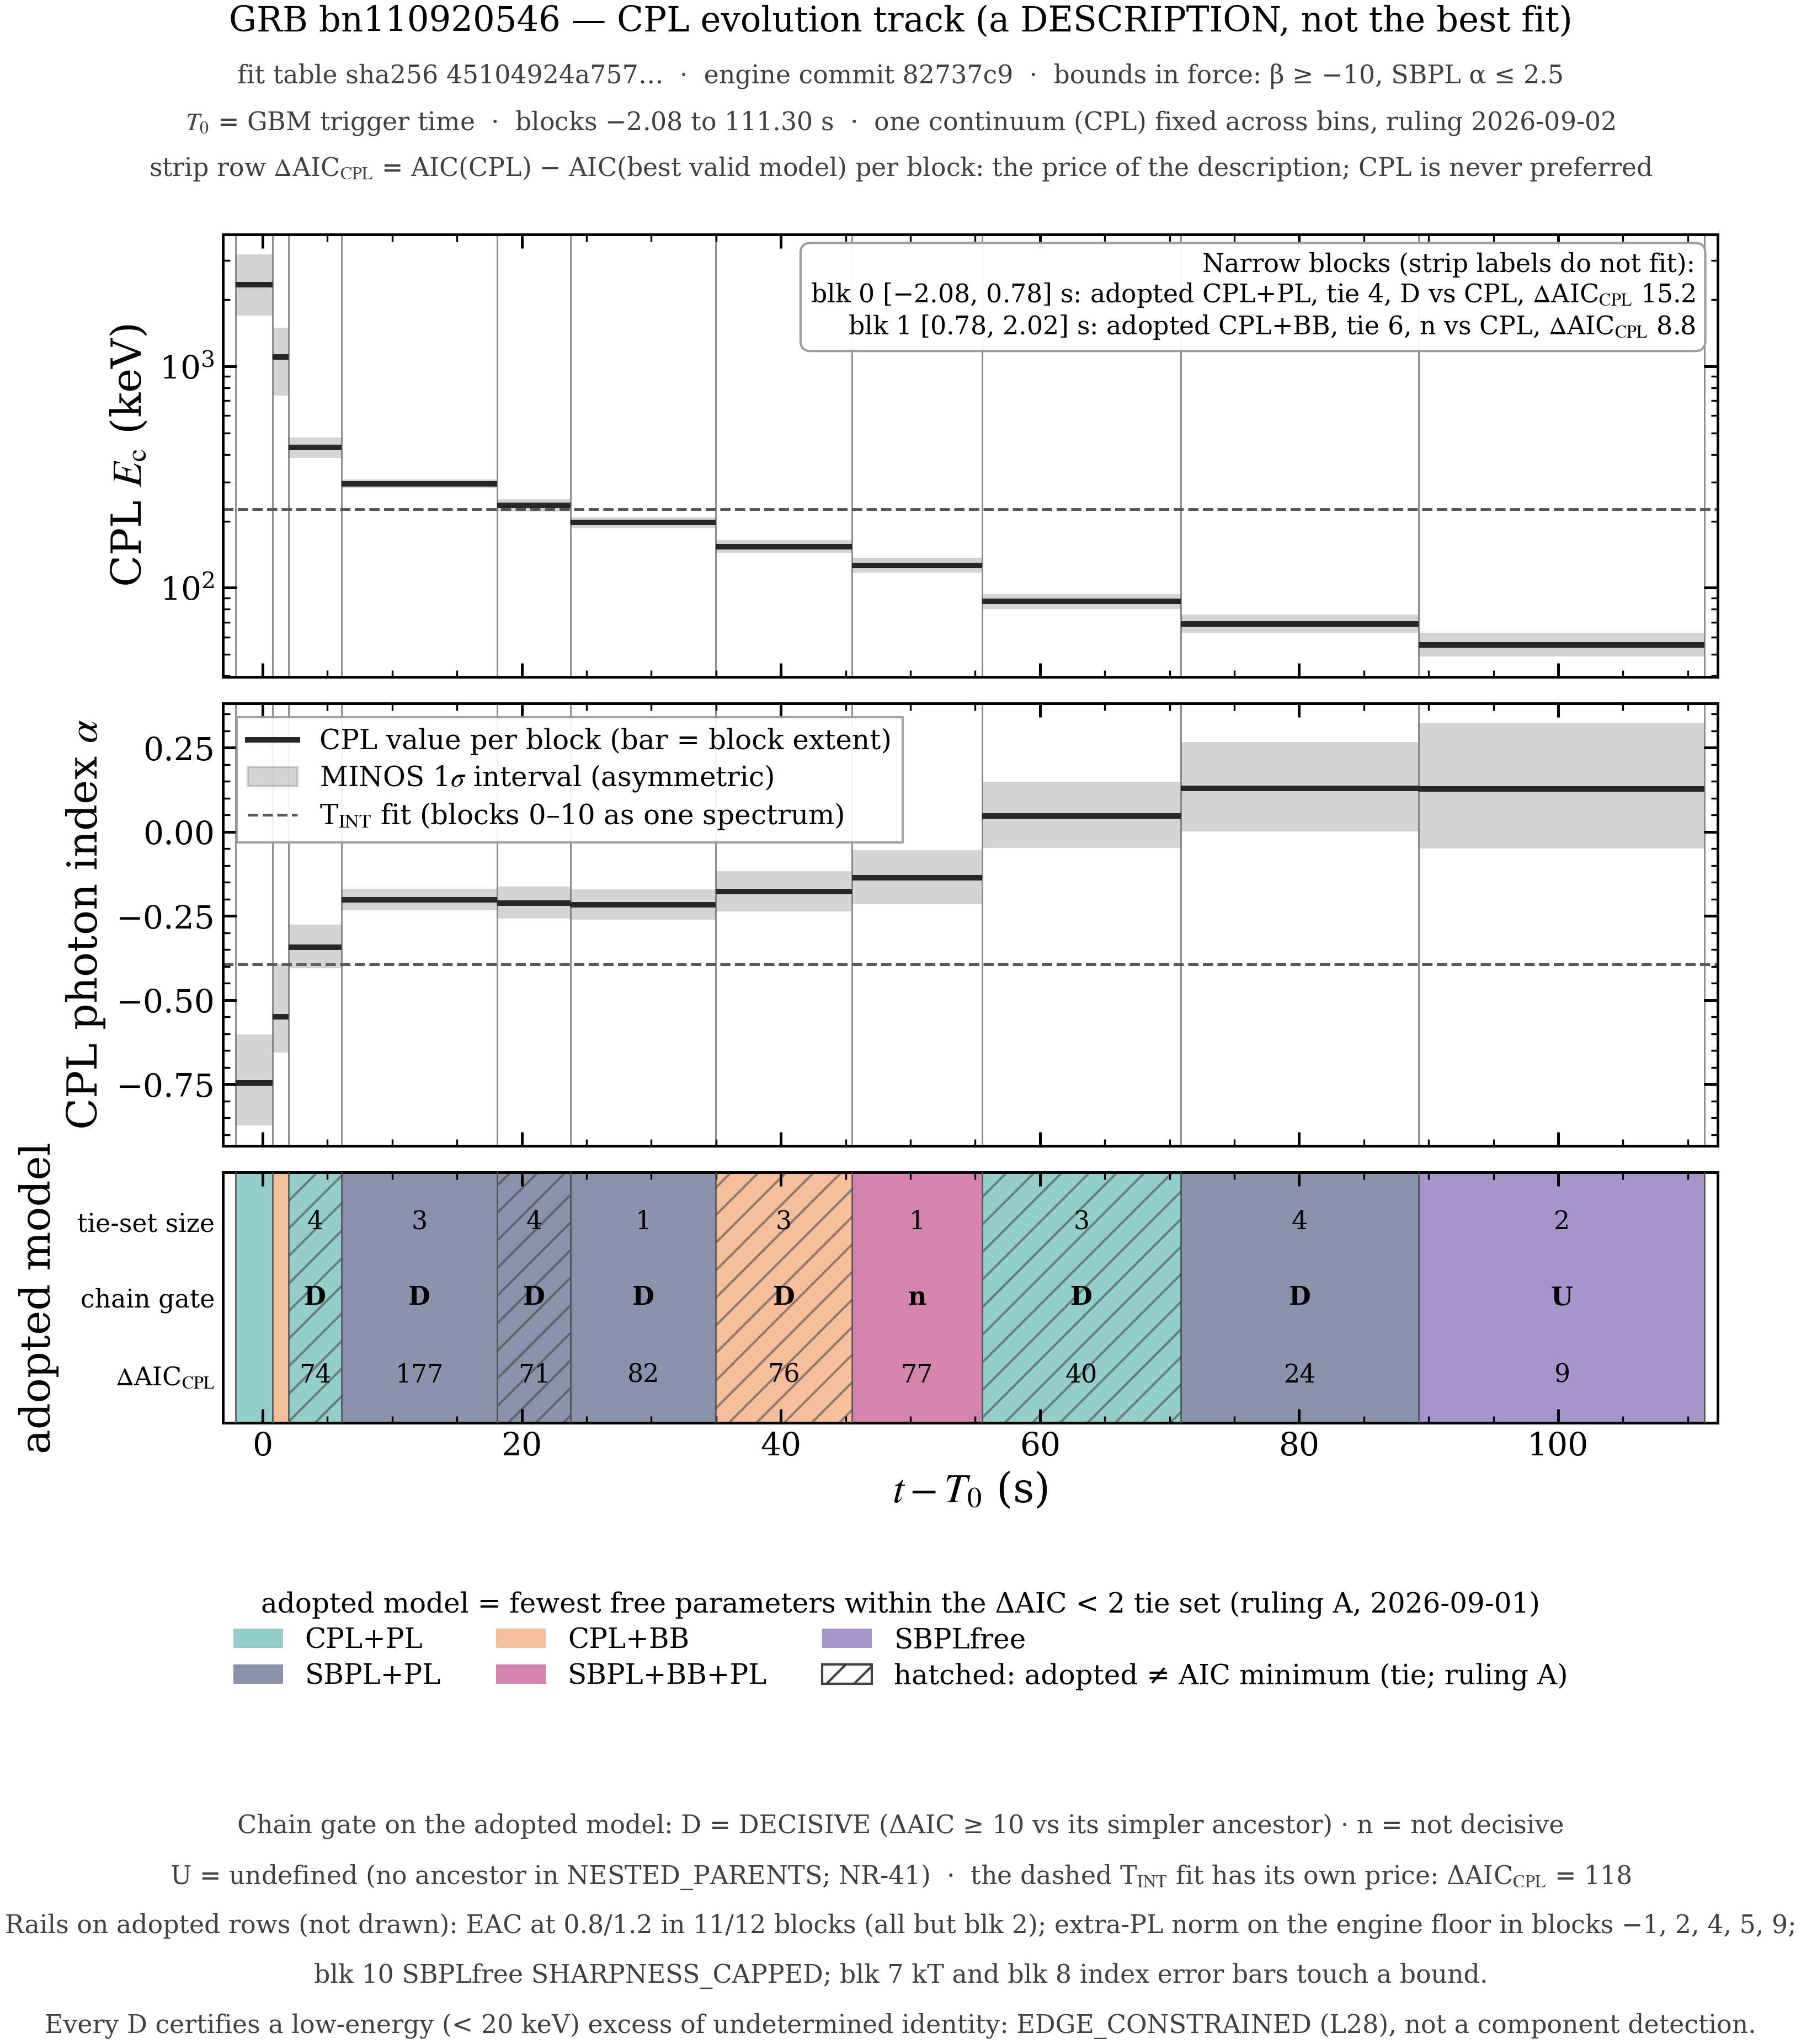

In [9]:
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
sys.path.insert(0, rel("scripts")); import plot_style; plot_style.apply_pub_style(); PUB = plot_style.PUB
FIG = rel(f"results/sweep106/{BURST}/{BURST}_step6_cpl_track.png"); SIDE = FIG.replace(".png", ".json")
ENGINE_REV = "82737c9"
PB_REV, EAC_REV = FTA.engine_bounds(FTA._engine_tree(rev=ENGINE_REV))
# per-block quantities for the figure: MINOS intervals + dAIC of CPL above the BEST VALID model (the ruling's wording) and above the ADOPTED model
rows_by_block = {int(r_["BLOCK"]): r_ for r_ in t}
for x in track:
    row = rows_by_block[x["block"]]
    x["index_minos"] = [abs(val(row, "CPL_INDEX_NEG_ERR")), abs(val(row, "CPL_INDEX_POS_ERR"))]
    x["xc_minos"] = [abs(val(row, "CPL_XC_NEG_ERR")), abs(val(row, "CPL_XC_POS_ERR"))]
    best_valid = arows[x["block"]]["argmin"]
    x["cpl_above_best_valid"] = val(row, "CPL_AIC") - val(row, f"{pref[best_valid]}_AIC")
    x["best_valid"] = best_valid
tint = [x for x in track if x["block"] == -1][0]
tr_track = [x for x in track if x["block"] >= 0]
NARROW = 3.0   # s: blocks narrower than this get their strip labels in the panel-1 box
fam = {"CPL+PL": PUB["c_nai_b"], "SBPL+PL": PUB["c_nai_a"], "CPL+BB": PUB["c_nai_d"], "SBPL+BB+PL": PUB["c_bgo"], "SBPLfree": PUB["c_lle"]}
C_TRACK, C_BAND, C_SEP = "0.15", "0.45", PUB["c_ref"]
for _k in ("ytick.major.size", "ytick.minor.size"):   # NIT-14 (round 9): the style layer reclaims x tick sizes only
    plt.rcParams[_k] = PUB["tick_major"] if "major" in _k else PUB["tick_minor"]
MINUS = lambda v, f: (f % v).replace("-", "−")
fig, axes = plt.subplots(3, 1, figsize=(10.5, 12.6), sharex=True, gridspec_kw=dict(height_ratios=[3, 3, 1.7]))
fig.subplots_adjust(top=0.875, bottom=0.305, hspace=0.07, left=0.11, right=0.97)
edges = sorted(set([x["t_start"] for x in tr_track] + [x["t_stop"] for x in tr_track]))
for ax, key, mkey, lab, logy in ((axes[0], "xc", "xc_minos", r"CPL $E_{\rm c}$ (keV)", True), (axes[1], "index", "index_minos", r"CPL photon index $\alpha$", False)):
    for x in tr_track:
        ax.plot([x["t_start"], x["t_stop"]], [x[key], x[key]], color=C_TRACK, lw=2.4, solid_capstyle="butt")
        ax.fill_between([x["t_start"], x["t_stop"]], x[key]-x[mkey][0], x[key]+x[mkey][1], color=C_BAND, alpha=0.30, lw=0)
    for e in edges: ax.axvline(e, color="0.55", lw=0.7, ls="-", zorder=0)
    ax.axhline(tint[key], color="0.35", ls="--", lw=1.2)
    ax.set_ylabel(lab)
    if logy: ax.set_yscale("log")
axes[1].plot([], [], color=C_TRACK, lw=2.4, label="CPL value per block (bar = block extent)")
axes[1].fill_between([], [], [], color=C_BAND, alpha=0.30, label=r"MINOS 1$\sigma$ interval (asymmetric)")
axes[1].plot([], [], color="0.35", ls="--", lw=1.2, label=r"T$_{\rm INT}$ fit (blocks 0–10 as one spectrum)")
axes[1].legend(loc="upper left", fontsize=PUB["legend_size"])
# panel-1 box: labels for the narrow blocks that cannot be printed in the strip
narrow = [x for x in tr_track if (x["t_stop"] - x["t_start"]) < NARROW]
lines = ["Narrow blocks (strip labels do not fit):"]
for x in narrow:
    a = arows[x["block"]]; gv = a["chain_gate_adopted"]
    gtxt = {"DECISIVE": f"D vs {gv['ancestor']}", "NOT_DECISIVE": f"n vs {gv['ancestor']}", "UNDEFINED_NO_ANCESTOR": "U"}[gv["verdict"]]
    lines.append(f"blk {x['block']} [{MINUS(x['t_start'], '%.2f')}, {MINUS(x['t_stop'], '%.2f')}] s: adopted {a['adopted']}, tie {len(a['tie_set'])}, {gtxt}, "
                 + r"$\Delta$AIC$_{\rm CPL}$" + f" {x['cpl_above_best_valid']:.1f}")
axes[0].text(0.985, 0.96, "\n".join(lines), transform=axes[0].transAxes, ha="right", va="top", fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.6", alpha=0.95))
# strip: adopted model, tie-set size, chain-gate letter, dAIC of CPL above best valid
ax = axes[2]
for x in tr_track:
    a = arows[x["block"]]; m = a["adopted"]; ga = a["chain_gate_adopted"]["verdict"]
    hatch = "//" if m != a["argmin"] else None
    ax.axvspan(x["t_start"], x["t_stop"], facecolor=fam.get(m, "0.6"), alpha=0.55, lw=0, hatch=hatch, edgecolor="0.25")
    if (x["t_stop"] - x["t_start"]) >= NARROW:
        xm = 0.5 * (x["t_start"] + x["t_stop"])
        ax.text(xm, 0.80, f"{len(a['tie_set'])}", ha="center", va="center", fontsize=11)
        ax.text(xm, 0.50, {"DECISIVE": "D", "NOT_DECISIVE": "n", "UNDEFINED_NO_ANCESTOR": "U"}[ga], ha="center", va="center", fontsize=11, fontweight="bold")
        ax.text(xm, 0.19, f"{x['cpl_above_best_valid']:.0f}", ha="center", va="center", fontsize=11)
for e in edges: ax.axvline(e, color="0.3", lw=0.6, zorder=3)
ax.set_ylim(0, 1); ax.set_yticks([0.19, 0.50, 0.80]); ax.set_yticklabels([r"$\Delta$AIC$_{\rm CPL}$", "chain gate", "tie-set size"], fontsize=11)
ax.tick_params(axis="y", which="both", length=0); ax.set_ylabel("adopted model", labelpad=8)
ax.set_xlabel(r"$t - T_0$ (s)")
axes[0].set_xlim(tr_track[0]["t_start"] - 1, tr_track[-1]["t_stop"] + 1)
# header (outside the axes; every line shorter than the axes width so bbox-tight does not grow the canvas)
fig.text(0.5, 0.985, f"GRB {BURST} — CPL evolution track (a DESCRIPTION, not the best fit)", ha="center", va="top", fontsize=15)
fig.text(0.5, 0.957, f"fit table sha256 {TAB_SHA[:12]}…  ·  engine commit {ENGINE_REV}  ·  bounds in force: β ≥ −10, SBPL α ≤ 2.5", ha="center", va="top", fontsize=11, color="0.25")
fig.text(0.5, 0.935, r"$T_0$ = GBM trigger time  ·  blocks −2.08 to 111.30 s  ·  one continuum (CPL) fixed across bins, ruling 2026-09-02", ha="center", va="top", fontsize=11, color="0.25")
fig.text(0.5, 0.913, r"strip row $\Delta$AIC$_{\rm CPL}$ = AIC(CPL) − AIC(best valid model) per block: the price of the description; CPL is never preferred", ha="center", va="top", fontsize=11, color="0.25")
# legend + footer (outside the axes; short lines)
handles = [Patch(facecolor=c, alpha=0.55, label=m) for m, c in fam.items()] + [Patch(facecolor="white", edgecolor="0.25", hatch="//", label="hatched: adopted ≠ AIC minimum (tie; ruling A)")]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.165), ncol=3, fontsize=PUB["legend_size"], frameon=False,
           title="adopted model = fewest free parameters within the ΔAIC < 2 tie set (ruling A, 2026-09-01)", title_fontsize=PUB["legend_size"])
rail_blocks = [int(r_["block"]) for r_ in A["rows"] if r_["rails_adopted"]]
plk_floor = [x["block"] for x in track if arows[x["block"]]["adopted"].endswith("+PL") and val(rows_by_block[x["block"]], pref[arows[x["block"]]["adopted"]] + "_PL_K") <= 1.01e-15]
plk_txt = ", ".join(MINUS(b_, "%d") for b_ in plk_floor)
foot = [
 "Chain gate on the adopted model: D = DECISIVE (ΔAIC ≥ 10 vs its simpler ancestor) · n = not decisive",
 rf"U = undefined (no ancestor in NESTED_PARENTS; NR-41)  ·  the dashed T$_{{\rm INT}}$ fit has its own price: ΔAIC$_{{\rm CPL}}$ = {tint['cpl_above_best_valid']:.0f}",
 f"Rails on adopted rows (not drawn): EAC at 0.8/1.2 in {len(rail_blocks)}/12 blocks (all but blk 2); extra-PL norm on the engine floor in blocks {plk_txt};",
 "blk 10 SBPLfree SHARPNESS_CAPPED; blk 7 kT and blk 8 index error bars touch a bound.",
 "Every D certifies a low-energy (< 20 keV) excess of undetermined identity: EDGE_CONSTRAINED (L28), not a component detection.",
]
for i_, line in enumerate(foot):
    fig.text(0.5, 0.118 - 0.024 * i_, line, ha="center", va="top", fontsize=11, color="0.25")
fig.savefig(FIG, dpi=300); plt.close(fig)
json.dump(dict(table_sha256=TAB_SHA, figure=os.path.basename(FIG), engine_commit=ENGINE_REV, engine_param_bounds_at_rev=PB_REV, eac_bounds=list(EAC_REV),
               error_band="MINOS asymmetric (CPL_INDEX_NEG_ERR/POS_ERR, CPL_XC_NEG_ERR/POS_ERR)", dAIC_on_figure="cpl_above_best_valid = AIC(CPL) - AIC(argmin over valid models)",
               track=track, adopted={str(b): arows[b]["adopted"] for b in arows}, argmin={str(b): arows[b]["argmin"] for b in arows},
               tie_set_size={str(b): len(arows[b]["tie_set"]) for b in arows}, chain_gate_adopted={str(b): arows[b]["chain_gate_adopted"] for b in arows},
               rails_adopted={str(b): arows[b]["rails_adopted"] for b in arows}, pl_k_floor_blocks=plk_floor, narrow_blocks_in_box=[x["block"] for x in narrow]), open(SIDE, "w"), indent=1)
print("figure:", FIG, "\nsha256:", sha(FIG), "\nsidecar:", SIDE, "sha256:", sha(SIDE))
from IPython.display import Image, display; display(Image(filename=FIG))

## 6. Rail census (NR-43) and thermal components (L24/L28)
`VALID = True` is not evidence of no rail: nuisance rails (EAC) are invisible to the validity gate. The three rail classes (bounds ruling 2026-09-02): (1) ours fighting the data → widened; (2) component absent → disclose; (3) the model cannot reach → disclose.

In [10]:
def at(v, lo, hi, tol=0.011): return (abs(v-lo) <= tol*max(1,abs(lo)), abs(v-hi) <= tol*max(1,abs(hi)))
print("A. EAC rails on the ADOPTED model (nuisance; box 0.8–1.2):")
n_rail = sum(1 for r_ in A["rows"] if r_["rails_adopted"])
print(f"   blocks with >=1 railed EAC: {n_rail}/12 all, {sum(1 for r_ in A['rows'] if r_['rails_adopted'] and int(r_['block'])>=0)}/11 time-resolved; rail-free: {[int(r_['block']) for r_ in A['rows'] if not r_['rails_adopted']]}")
print("   -> every flux/normalisation inherited from an adopted model carries these rails; EAC_*_ERR = 0 is never an uncertainty.")
print("\nB. Shape rails at the WIDENED bounds:")
beta_cols = [c for c in t.colnames if c.endswith("_BETA")]
for c in beta_cols:
    v = np.array([val(r_, c) for r_ in t]); n10 = int(np.sum(v <= -9.99)); n5 = int(np.sum(np.abs(v+5) < 0.01))
    if n10 or n5: print(f"   {c:16s} at -10 wall: {n10}/12 rows {[int(t['BLOCK'][i]) for i in range(len(t)) if v[i] <= -9.99]} | at old -5: {n5}")
print("   Band-family beta never touches -10 (softest", f"{min(val(r_,'BAND_BETA') for r_ in t):.2f});", "SBPL-family beta hits -10 in the blocks where SBPL_VALID=False -> class 3: fixed-smoothness SBPL cannot make an exponential cutoff; XSPEC limit reached -> DISCLOSED, not widened further")
for c in [c for c in t.colnames if c.startswith("SBPL") and c.endswith("_ALPHA")]:
    v = np.array([val(r_, c) for r_ in t]); hit = [int(t["BLOCK"][i]) for i in range(len(t)) if v[i] >= 2.47]
    if hit: print(f"   {c:16s} at the 2.5 ceiling in blocks {hit} (composite; VALID=False there; not adopted anywhere)")
print("   BOUND_CAPPED column values:", sorted(set(str(x) for x in t["BOUND_CAPPED"])), "-> the L9 diagnosis never fires; rail census stays MANUAL (register debt)")
print("\nC. Thermal components (L24/L28): 3.92 kT < 20 keV = EDGE_CONSTRAINED; retained in the record, excluded from any population claim")
for b in (1, 6, 7):
    m = arows[b]["adopted"]; p = pref[m]; row = t[[int(x) for x in t["BLOCK"]].index(b)]
    kt = val(row, f"{p}_KT"); ke = val(row, f"{p}_KT_ERR")
    print(f"   blk {b:2d} adopted {m:12s} kT = {kt:.2f} ± {ke:.2f} keV -> 3.92 kT = {3.92*kt:.1f} keV -> {'EDGE_CONSTRAINED' if 3.92*kt < 20 else ('EDGE_MARGINAL' if 3.92*kt < 30 else 'clear')}")
row = t[[int(x) for x in t["BLOCK"]].index(-1)]
print(f"   T_INT: adopted SBPL+PL carries no BB; SBPL+BB+PL kT = {val(row,'SBPLBBPL_KT'):.4f} keV on the 1 keV floor (VALID=False) -> 'T_INT thermal component: NOT MEASURABLE (railed)', never 'no thermal component' (L24)")
print("   L25: xb/(3.92 kT) identity test not applicable — no adopted model carries both a break and a BB.")

A. EAC rails on the ADOPTED model (nuisance; box 0.8–1.2):
   blocks with >=1 railed EAC: 11/12 all, 10/11 time-resolved; rail-free: [2]
   -> every flux/normalisation inherited from an adopted model carries these rails; EAC_*_ERR = 0 is never an uncertainty.

B. Shape rails at the WIDENED bounds:
   SBPL_BETA        at -10 wall: 5/12 rows [0, 2, 7, 8, 10] | at old -5: 0
   DSBPL_BETA       at -10 wall: 1/12 rows [0] | at old -5: 0
   SBPLF_BETA       at -10 wall: 1/12 rows [0] | at old -5: 0
   DSBPLF_BETA      at -10 wall: 1/12 rows [0] | at old -5: 0
   BANDRCPL_BETA    at -10 wall: 1/12 rows [0] | at old -5: 0
   SBPLCUT_BETA     at -10 wall: 5/12 rows [0, 2, 7, 8, 10] | at old -5: 0
   SBPLPL_BETA      at -10 wall: 2/12 rows [0, 10] | at old -5: 0
   SBPLCPL_BETA     at -10 wall: 2/12 rows [0, 10] | at old -5: 0
   BANDBBPL_BETA    at -10 wall: 1/12 rows [0] | at old -5: 0
   BANDBBCPL_BETA   at -10 wall: 1/12 rows [10] | at old -5: 0
   SBPLBB_BETA      at -10 wall: 3/12 rows [0,

## 6b. What the DECISIVE extra component actually is
The chain gate says a second component is needed (DECISIVE vs the bare continuum in 8/11 adopted, 6/11 argmin time-resolved blocks). The verifier's unprompted finding U1: **that component is a low-energy excess, not a high-energy power law.** The engine's extra PL pivots at 100 MeV with a normalisation floor of 1e-15; in the adopted PL rows the normalisation sits on that floor and the index is ≈ −3.6, so the PL contributes only below ~20 keV. The adopted BBs (kT 1–3 keV) occupy the same energies. Both are EDGE_CONSTRAINED by protocol L28 (3.92 kT < 20 keV; Tierney+2013 / Ravasio+2019 App. B), and the NaI effective-area corrections are railed in 11/12 adopted fits.

In [11]:
E_piv = 1.0e5   # keV, the engine's extra-PL pivot (100 MeV) as read by the verifier from _setup_extra_pl
print(f"{'blk':>3s} {'adopted':12s} {'PL index':>9s} {'PL K (floor 1e-15)':>19s} {'N_PL(10 keV)':>13s} {'N_PL(100 keV)':>14s} {'ratio 10/100':>13s}")
for r_ in A["rows"]:
    b = int(r_["block"]); m = r_["adopted"]
    if not m.endswith("+PL"): continue
    row = t[[int(x) for x in t["BLOCK"]].index(b)]; p = pref[m]
    idx = val(row, f"{p}_PL_INDEX"); K = val(row, f"{p}_PL_K")
    n10 = K * (10.0 / E_piv) ** idx; n100 = K * (100.0 / E_piv) ** idx
    print(f"{b:3d} {m:12s} {idx:9.2f} {K:19.3g}{' *floor*' if K <= 1.01e-15 else ''}{'':>{0 if K <= 1.01e-15 else 8}} {n10:13.3g} {n100:14.3g} {n10/n100:13.0f}")
print("-> a photon index of -3.6 makes the 'PL' ~4000x stronger at 10 keV than at 100 keV: a LOW-ENERGY excess. With K on the floor and the index free, (K, index) are degenerate; the PL parameters are NOT measured, only the excess shape is.")
print("\nAdopted BBs (same energies):", ", ".join(f"blk {b}: kT {val(t[[int(x) for x in t['BLOCK']].index(b)], pref[arows[b]['adopted']]+'_KT'):.2f} keV" for b in (1, 6, 7)))
r10 = [r_ for r_ in A["rows"] if int(r_["block"]) == 10][0]; row10 = t[[int(x) for x in t["BLOCK"]].index(10)]
print(f"\nblock 10 adopted SBPLfree: SCALE = {val(row10,'SBPLF_SCALE'):.3f} ± {val(row10,'SBPLF_SCALE_ERR') if 'SBPLF_SCALE_ERR' in t.colnames else float('nan'):.3f}; engine stamp SHARPNESS_CAPPED = {row10['SHARPNESS_CAPPED']} -> its 0.75 margin over CPL+BB is an upper limit by the engine's own rule")
print("\nCONSEQUENCE: every DECISIVE verdict in this burst certifies the statistical NEED for a low-energy excess below ~20 keV of UNDETERMINED identity (steep PL or 1–3 keV BB interchangeably), with railed EAC. It is EDGE_CONSTRAINED (L28): retained in the record, excluded from any component-detection or population claim.")

blk adopted       PL index  PL K (floor 1e-15)  N_PL(10 keV)  N_PL(100 keV)  ratio 10/100
 -1 SBPL+PL          -3.62               1e-15 *floor*         0.302       7.24e-05          4167
  0 CPL+PL           -3.07            9.81e-14                 0.191       0.000161          1180
  2 CPL+PL           -3.67               1e-15 *floor*         0.476       0.000102          4670
  3 SBPL+PL          -3.39            1.39e-14                  0.52        0.00021          2471
  4 SBPL+PL          -3.67               1e-15 *floor*          0.47       0.000101          4655
  5 SBPL+PL          -3.65               1e-15 *floor*         0.416       9.21e-05          4517
  7 SBPL+BB+PL       -2.14            4.55e-10                  0.16        0.00117           137
  8 CPL+PL           -3.41            5.08e-15                 0.227       8.77e-05          2585
  9 SBPL+PL          -3.57               1e-15 *floor*         0.197       5.27e-05          3748
-> a photon index of -3.6 ma

## 7. What may NOT be claimed from this step
- **No two-break claim of any strength.** The four two-break-capable models (DSBPL, DSBPLfree, SBPLfree, BandR+CPL) have no ancestor in `NESTED_PARENTS`, so a DECISIVE verdict for them is undefined (NR-41; PI ruling pending). Block 10's SBPLfree winner is a **preference inside a 2-member tie** (over CPL+BB by 0.75), not a structure claim, "and must say so in those words" (L31).
- **No single winner in a tie.** 9 of 11 time-resolved blocks are tie sets; the adopted model is the fewest-parameter member (ruling A), and physical quantities carry the across-tie spread.
- **No "extra component detected" language.** The DECISIVE verdicts certify a low-energy (<20 keV) excess of undetermined identity — steep PL (index ≈ −3.6, normalisation on the engine floor) or BB (kT 1–3 keV) interchangeably — with EAC railed in 11/12 adopted fits. EDGE_CONSTRAINED (L28): not a component detection, not population material (§6b).
- **No thermal "detection".** Every BB kT on an adopted model is 1.0–3.1 keV (3.92 kT = 4–12 keV, below the 20 keV edge): EDGE_CONSTRAINED (L28). T_INT thermal: not measurable (railed).
- **T_INT is not TRACKED.** Its 7.81 margin exists only because the identical-likelihood twin SBPL+CPL was invalidated by a rail (§3).
- **Tie counts are knife-edge.** Members sit at ΔAIC = 2.000 exactly in blocks 0 and 3, and block 4's adoption flipped on 0.14; "9/11 ties" is a count under the PI's threshold, not a robust classification.
- **No calibrated significance** ("required at Nσ") from AIC/BIC/LRT at an additive component's zero boundary.
- **No absolute AIC or BIC.** The table carries a constant +6.0000 offset (2 × 3 EAC nuisances); only margins are quoted (NR-44).
- **The CPL track is a description**, not a best fit: CPL is above the adopted model by 8.5–177 in every block.
- **Per-burst only.** Nothing here transfers to un-walked bursts; the campaign `model_preference.ecsv` remains SUSPECT for them (NR-26).
- **All numbers are PROVISIONAL** until the freeze (BurstWalkthrough rule).

## 8. Verification ledger for this step

In [12]:
for name in (f"NUMBERS_QC_{BURST}_step6.md", f"NUMBERS_QC_{BURST}_step6_widened.md", f"FIT_TABLE_AUDIT_{BURST}.md", "VISION_QC.md"):
    p = rel(f"results/sweep106/{BURST}/{name}")
    if os.path.exists(p):
        txt = open(p).read()
        verdict = [l for l in txt.splitlines() if "VERDICT" in l.upper() or "verdict" in l][:2]
        print(f"{name:42s} sha {sha(p)[:12]}  {' | '.join(v.strip()[:90] for v in verdict) if verdict else ''}")
    else:
        print(f"{name:42s} — NOT ON DISK (pending)")
print("\nfigure sha registered in VISION_QC.md?", sha(FIG)[:16] in open(rel(f"results/sweep106/{BURST}/VISION_QC.md")).read())
pin2 = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))["gate_verdicts_hash_bound"][f"{BURST}_step6_WIDENED"]
print("\npinned numbers verdict:", pin2.get("numbers_verdict", "")[:400])

NUMBERS_QC_bn110920546_step6.md            sha 119136a12a0c  ## Claim-by-claim verdicts | will render raw `nan`. **Verdict: R3 passes for adopted values, fails for the table as a
NUMBERS_QC_bn110920546_step6_widened.md    sha adcf3fb49ba9  ## Overall verdict
FIT_TABLE_AUDIT_bn110920546.md             sha e06a786f3a23  
VISION_QC.md                               sha 6b1fea86cfb0  VERDICT: PASS-WITH-NITS (round 1, 2026-08-30) — step-1 figure clean to deliver at the | **VERDICT: PASS-WITH-NITS** (2 nits, zero label–primitive mismatches)

figure sha registered in VISION_QC.md? True

pinned numbers verdict: A9 2026-09-02 (NUMBERS_QC_bn110920546_step6_widened.md): NUMBERS PASS — 13/13 traceable, 11 exact; CLAIM PROMOTION CONDITIONAL FAIL — DECISIVE extra components are low-energy (<20 keV) edge features (PL index ~-3.6 with PL_K on the 1e-15 floor at the 100 MeV pivot, or BB kT 1-3 keV) with EAC railed 11/12; blk-4 adopted flipped CPL+BB->SBPL+PL between generations (0.14 AIC); T_INT margin 